# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** Divya Saxena
**Register Number:** AP24110011570  
**Date:** 27-08-2026

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [17]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [18]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [20]:
# 1. Create 5 random missing values in the tip column
tips_tip_missing = tips.copy()

np.random.seed(42)

missing_idx = np.random.choice(tips_tip_missing.index, size=5, replace=False)

tips_tip_missing.loc[missing_idx, 'tip'] = np.nan

print("Missing values:", tips_tip_missing['tip'].isna().sum())

# 2. Fill missing tip using median tip grouped by time
time_medians = tips_tip_missing.groupby('time')['tip'].transform('median')

tips_tip_filled = tips_tip_missing.copy()
tips_tip_filled['tip'] = tips_tip_missing['tip'].fillna(time_medians)

print("Remaining missing:", tips_tip_filled['tip'].isna().sum())

Missing values: 5
Remaining missing: 0


**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:* 

Group-wise mean/median can be better because different groups may have different typical values. For example, Lunch and Dinner customers may have different average tip amounts, so filling missing tips with the overall mean could give inaccurate values. Using the median tip for each time group preserves these differences and gives a more realistic replacement.

## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [5]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [6]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


,day,day_Thur,day_Fri,day_Sat,day_Sun
0,Sun,False,False,False,True
1,Sun,False,False,False,True
2,Sun,False,False,False,True
3,Sun,False,False,False,True
4,Sun,False,False,False,True


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:*


In [ ]:
# Encode time as 0/1
tips_enc['time_encoded'] = tips_enc['time'].map({
    'Lunch': 0,
    'Dinner': 1
})

tips_enc[['time', 'time_encoded']].head()

,time,time_encoded
0,Dinner,1
1,Dinner,1
2,Dinner,1
3,Dinner,1
4,Dinner,1


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*

Label encoding day as Thur=0, Fri=1, Sat=2, Sun=3 can be misleading because it makes the model think the categories have a meaningful numerical order and distance. For example, the model may interpret Sun (3) as being “greater than” Sat (2), even though the days are simply different categories with no such relationship. Therefore, one-hot encoding is more appropriate for day.

## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [8]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [23]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:*

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [24]:
print("Mean:", tips_enc['total_bill_standardized'].mean())
print("Standard deviation:", tips_enc['total_bill_standardized'].std())

# Min-Max scaling for size
tips_enc['size_scaled'] = min_max_scale(tips_enc['size'])

tips_enc[['size', 'size_scaled']].head()

Mean: -6.028875031263658e-17
Standard deviation: 1.0


,size,size_scaled
0,2,0.2
1,3,0.4
2,3,0.4
3,2,0.2
4,4,0.6


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:*

Min-max scaling changes the values to a fixed range, usually 0 to 1. However, it is sensitive to extreme outliers because the minimum and maximum determine the entire range. I would prefer min-max scaling when I need values in a specific range and there are no major outliers.

Standardization transforms the values so that the mean is approximately 0 and the standard deviation is approximately 1. It is generally more suitable when the data contains outliers because it is less directly affected by extreme minimum/maximum values.


## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [25]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


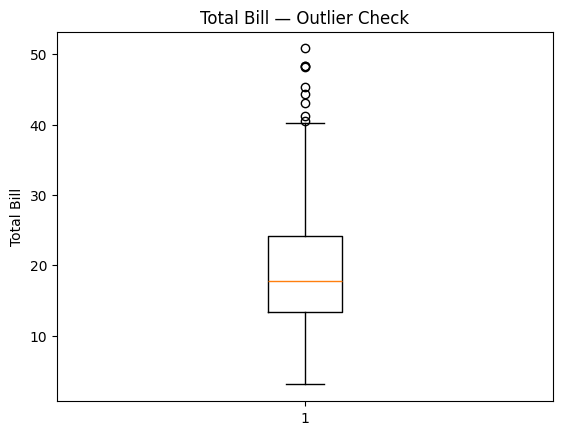

In [26]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [27]:
# Write your answer here
# 1. IQR outlier check for the tip column

Q1 = tips['tip'].quantile(0.25)
Q3 = tips['tip'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_tip = tips[
    (tips['tip'] < lower_bound) |
    (tips['tip'] > upper_bound)
]

print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers_tip)}")

# 2. Cap the outliers instead of dropping them
tips_capped = tips.copy()

tips_capped['tip'] = tips_capped['tip'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("\nAfter capping:")
print(tips_capped['tip'].describe())

Bounds: [-0.34, 5.91]
Number of outliers: 9

After capping:
count    244.000
mean       2.950
std        1.226
min        1.000
25%        2.000
50%        2.900
75%        3.562
max        5.906
Name: tip, dtype: float64


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:*

Capping outliers can be preferable because it keeps all the data and rows while reducing the influence of extreme values. Dropping outliers is better when the values are clearly errors, measurement mistakes, or invalid observations that should not be part of the analysis.

## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [28]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [29]:
# Write your answer here

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (170, 4)
Test shape: (74, 4)


**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:*

It is important to split the data before training so the test set remains unseen data that can fairly evaluate how well the model performs on new data. If the model trains on the test data too, the evaluation can be overly optimistic and may not reflect its real-world performance.


# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [32]:
from PIL import Image
import numpy as np
import pandas as pd
import os

# Find image files in the current folder
filenames = [
    f for f in os.listdir('.')
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))
]

normalized_images = []
stats = []

for filename in filenames:
    img_array = np.array(Image.open(filename))

    # Normalize pixels from 0-255 to 0-1
    img_normalized = img_array / 255.0

    # Store normalized image
    normalized_images.append(img_normalized)

    # Store statistics
    stats.append({
        'filename': filename,
        'min_pixel_before': img_array.min(),
        'max_pixel_before': img_array.max(),
        'min_pixel_after': img_normalized.min(),
        'max_pixel_after': img_normalized.max()
    })

# Create DataFrame
normalization_df = pd.DataFrame(stats)

print("Images found:", len(filenames))
normalization_df

Images found: 1


,filename,min_pixel_before,max_pixel_before,min_pixel_after,max_pixel_after
0,image.png,0,255,0.0,1.0


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [ ]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [33]:
from PIL import Image
import numpy as np
import pandas as pd

target_size = (128, 128)

processed_images = []
shape_info = []

for filename in filenames:
    # Open image
    img = Image.open(filename)

    # Resize to 128 x 128
    img_resized = img.resize(target_size)

    # Convert to NumPy array
    img_array = np.array(img_resized)

    # Normalize to 0-1
    img_normalized = img_array / 255.0

    # Store processed image
    processed_images.append(img_normalized)

    # Store filename and shape
    shape_info.append({
        'filename': filename,
        'shape': img_normalized.shape
    })

# Create DataFrame
shape_df = pd.DataFrame(shape_info)

shape_df

,filename,shape
0,image.png,"(128, 128, 3)"


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

*Your answer:*

Every image needs the same shape because a model expects a fixed-size input so it can process all images consistently. If images have different sizes, they cannot be combined into the same input batch, which can cause shape errors and prevent the model from processing them together.


# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [34]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [35]:
# Write your answer here
raw_text = "Machine Learning is AMAZING!!! I built 2 projects in 2026."

import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)

Before: Machine Learning is AMAZING!!! I built 2 projects in 2026.
After: ['machine', 'learning', 'is', 'amazing', 'i', 'built', '2', 'projects', 'in', '2026']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [36]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'2': 0, '2026': 1, 'amazing': 2, 'built': 3, 'i': 4, 'in': 5, 'is': 6, 'learning': 7, 'machine': 8, 'projects': 9}
Original tokens: ['machine', 'learning', 'is', 'amazing', 'i', 'built', '2', 'projects', 'in', '2026']
Encoded as IDs:   [8, 7, 6, 2, 4, 3, 0, 9, 5, 1]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [37]:
# Write your answer here
# 1. Build vocabulary and word-to-ID mapping
vocabulary = sorted(set(tokens))

word_to_id = {
    word: idx
    for idx, word in enumerate(vocabulary)
}

# 2. Encode the tokens into numeric IDs
encoded_tokens = [word_to_id[word] for word in tokens]

print("Original tokens:", tokens)
print("Encoded IDs:", encoded_tokens)

# 3. Build a DataFrame showing the full mapping
word_id_df = pd.DataFrame(
    list(word_to_id.items()),
    columns=['word', 'id']
).sort_values('id').reset_index(drop=True)

print("\nWord-to-ID mapping:")
word_id_df

Original tokens: ['machine', 'learning', 'is', 'amazing', 'i', 'built', '2', 'projects', 'in', '2026']
Encoded IDs: [8, 7, 6, 2, 4, 3, 0, 9, 5, 1]

Word-to-ID mapping:


,word,id
0,2,0
1,2026,1
2,amazing,2
3,built,3
4,i,4
5,in,5
6,is,6
7,learning,7
8,machine,8
9,projects,9


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:*

Word-to-ID encoding can create a misleading numerical relationship between words. For example, if machine = 8 and learning = 7, a model might incorrectly assume that machine is greater than or somehow more related to learning because of their numeric IDs. However, word IDs are just arbitrary labels and have no meaningful order or distance.

# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Order of preprocessing steps

A typical order would be:

Load data → inspect/clean missing values → encode categorical data → detect/handle outliers → scale numeric features → split into train/test sets → train the model.

This order helps ensure the data is clean and in a suitable numerical format before modeling. However, in real ML workflows, fitting preprocessing steps such as imputation, scaling, and encoding should be done using the training set only to avoid data leakage into the test set.

2. Why is preprocessing part of "data work"?

Preprocessing is part of data work because raw data is often incomplete, inconsistent, categorical, or not in a format that a model can understand effectively. The model does not automatically know how to handle missing values, encode categories, remove bad data, or choose appropriate feature scales, so these decisions must be made during data preparation.

3. Image preprocessing vs text preprocessing

Both image and text preprocessing convert raw data into a numerical representation that a machine-learning model can work with. For images, pixel values are normalized from 0–255 to 0–1; for text, words are converted into numeric IDs. In both cases, preprocessing transforms the original data into a consistent numerical form while preserving useful information.

4. One concept I'm still unsure about

One concept I would still like to understand better is when to choose standardization versus min-max scaling, especially when the dataset contains extreme outliers. I understand that min-max scaling puts values between 0 and 1, while standardization centers them around 0, but I would like more practice deciding which one is better for a particular model and dataset.